# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [1]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.9 MB/s eta 0:00:00
✅ Dependencies ready


In [28]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score # my addition
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [4]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
  "analysis": 0,
  "question": 1,
  "news_share": 2,
  "opinion": 3
}

# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'analysis': 0, 'question': 1, 'news_share': 2, 'opinion': 3}
Number of labels: 4


In [5]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving raw_posts.csv to raw_posts.csv
Uploaded: raw_posts.csv


In [6]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['id', 'text', 'label', 'title', 'body', 'source_url', 'notes']
Total examples: 200

Label distribution:
label
analysis      50
question      50
news_share    50
opinion       50
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


In [7]:
df

,id,text,label,title,body,source_url,notes,label_id
0,1,Leadership at big tech companies are willing t...,analysis,Leadership at big tech companies are willing t...,There was a big sell off with regards to hyper...,https://www.reddit.com/r/stocks/comments/1ud0y...,post_id=1ud0ya3; manual review (Milestone 1 pi...,0
1,2,Bought 50 shares of AIPO ETF\n\nThis trade was...,analysis,Bought 50 shares of AIPO ETF,"This trade was about $1700, which is sizeable ...",https://www.reddit.com/r/stocks/comments/1uczx...,post_id=1uczxy4; manual review (Milestone 1 pi...,0
2,3,How I Discovered the TSEM Stock\n\nMy current ...,analysis,How I Discovered the TSEM Stock,"My current portfolio includes SNDK, MU, CRDO, ...",https://www.reddit.com/r/stocks/comments/1ucyl...,post_id=1ucylw6; manual review (Milestone 1 pi...,0
3,4,Semis vs. Software & MSFT's conundrum\n\nIf I ...,analysis,Semis vs. Software & MSFT's conundrum,"If I were at a hedge fund, I would make the fo...",https://www.reddit.com/r/stocks/comments/1ucp3...,post_id=1ucp36c; manual review (Milestone 1 pi...,0
4,5,$CHWY is an Acquisition Target at these Levels...,analysis,$CHWY is an Acquisition Target at these Levels,"Over the past 30 days, I have purchased 250,00...",https://www.reddit.com/r/stocks/comments/1ucmi...,post_id=1ucmier; manual review (Milestone 1 pi...,0
...,...,...,...,...,...,...,...,...
195,196,Tesla stock is tumbling. Blame BYD\n\nhttps://...,opinion,Tesla stock is tumbling. Blame BYD,https://qz.com/byd-tesla-gods-eye-self-driving...,https://www.reddit.com/r/stocks/comments/1inyd...,post_id=1inydfk; heuristic label; reviewed aga...,3
196,197,Big gains today\n\nI entered the market about ...,opinion,Big gains today,I entered the market about two months ago and ...,https://www.reddit.com/r/stocks/comments/1u6lq...,post_id=1u6lqtl; heuristic label; reviewed aga...,3
197,198,The US Economy is in Trouble and I’m going to ...,opinion,The US Economy is in Trouble and I’m going to ...,I work at a big name casino and have noticed o...,https://www.reddit.com/r/stocks/comments/1jg5a...,post_id=1jg5aaz; heuristic label; reviewed aga...,3
198,199,There is a bloodbath\n\nBut no real talk about...,opinion,There is a bloodbath,But no real talk about it? Even if many stocks...,https://www.reddit.com/r/stocks/comments/1txto...,post_id=1txtobk; heuristic label; reviewed aga...,3


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [11]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 140 examples
Validation: 30 examples
Test: 30 examples

Train label distribution:
label
analysis      35
opinion       35
news_share    35
question      35
Name: count, dtype: int64

Test label distribution:
label
analysis      8
news_share    8
opinion       7
question      7
Name: count, dtype: int64


In [17]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/140 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [18]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 4


In [29]:
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     predictions = np.argmax(logits, axis=-1)
#     return {"accuracy": accuracy_score(labels, predictions)}


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="macro"),  # must be macro, not weighted
    }

In [48]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=3, # (~10% of ~27 total steps): enough to stabilize early DistilBERT updates on a tiny dataset without spending the whole run in LR ramp-up (unlike warmup_steps=50, which exceeded total training steps).
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1", # more appropriate than accuracy considering class performance
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.162781,0.666667,0.653907
2,0.094167,1.176396,0.566667,0.527807
3,0.090119,1.129963,0.633333,0.617748


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [49]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.567

Per-class metrics (fine-tuned model):
              precision    recall  f1-score   support

    analysis       0.62      0.62      0.62         8
    question       0.50      0.43      0.46         7
  news_share       0.60      0.75      0.67         8
     opinion       0.50      0.43      0.46         7

    accuracy                           0.57        30
   macro avg       0.56      0.56      0.55        30
weighted avg       0.56      0.57      0.56        30



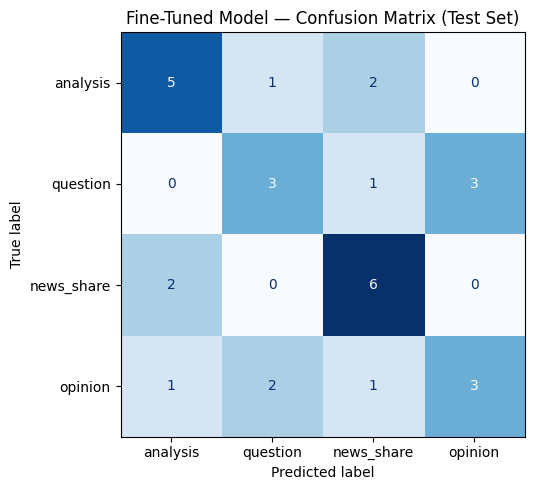

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [50]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [51]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 13 / 30

--- #1 ---
Text:      The SEC Is Going Too Easy on Insider Trading - Investors need to know more about executives’ stock-selling plans.

https://www.bloomberg.com/opinion/articles/2021-12-28/the-sec-is-going-too-easy-on-in...
True:      analysis
Predicted: news_share  (confidence: 0.92)

--- #2 ---
Text:      Lululemon shares tumble 20% as it cuts full-year guidance, citing ‘dynamic macroenvironment’

Lululemon beat Wall Street expectations for fiscal first-quarter earnings Thursday, but cut its full-year ...
True:      analysis
Predicted: news_share  (confidence: 0.64)

--- #3 ---
Text:      AI is disruptive. Individual companies have never been more volatile. What’s the argument to not just buy indexes?

Looking at the price trend, indexes have been the most stable in this AI bull market...
True:      question
Predicted: opinion  (confidence: 0.74)

--- #4 ---
Text:      How I Discovered the TSEM Stock

My current portfolio includes SNDK, MU, CRDO, INTC, T

### Demo: live inference on sample posts

In [ ]:
# ── Live inference helper (demo + README sample classifications) ───────────────

def classify_post(text, model=None, true_label=None):
    """Run fine-tuned model on one post; print label, confidence, and per-class probs."""
    if model is None:
        model = trainer.model
    model.eval()
    device = next(model.parameters()).device

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)[0].cpu().numpy()
    pred_id = int(probs.argmax())
    pred_label = ID_TO_LABEL[pred_id]
    confidence = float(probs[pred_id])

    preview = text.strip().replace("\n", " ")
    if len(preview) > 140:
        preview = preview[:140] + "..."

    print("=" * 62)
    print(f"Post: {preview}")
    if true_label is not None:
        ok = pred_label == true_label
        print(f"True label: {true_label}  →  {'✓' if ok else '✗'}")
    print(f"Predicted:  {pred_label}  (confidence: {confidence:.2f})")
    print("Probabilities:")
    for i, name in enumerate(label_names):
        bar = "█" * int(probs[i] * 20)
        print(f"  {name:12} {probs[i]:.3f}  {bar}")
    print()
    return pred_label, confidence


# Title substrings → expected label (must exist in test_df for held-out eval)
DEMO_SAMPLES = [
    ("SK Hynix overtakes", None),           # news_share — narrate as CORRECT in demo
    ("Semis vs. Software", None),           # analysis
    ("MSFT is nowhere near", None),         # opinion
    ("AI is disruptive", None),             # question
    ("MU or SNDK", None),                   # question — narrate as WRONG (often → opinion)
]

print("Fine-tuned model — demo sample classifications\n")
for title_key, _ in DEMO_SAMPLES:
    hits = test_df[test_df["title"].str.contains(title_key, case=False, na=False)]
    if hits.empty:
        print(f"⚠️  '{title_key}' not found in test_df — skip or paste text into classify_post() below\n")
        continue
    row = hits.iloc[0]
    classify_post(row["text"], true_label=row["label"])


---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [52]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [53]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """

You are classifying Reddit posts from r/stocks (US public-market investing).

Assign each post to exactly one discourse type based on its primary purpose.

analysis: A post that makes a structured investment argument using reasoning, data, fundamentals, technicals, or macro context.
Example: "Since semi stocks have soared while software stocks have cratered… This brings me to Microsoft: they have the best of both worlds but are treated as the worst… TLDR; MSFT seems oversold to me."

question: A post that primarily asks the community for advice, information, or input rather than presenting an argument.
Example: "MU or SNDK which one looks better going forward? Right now I'm stuck between whether MU is still the safer bet… or if sentiment really rotates into memory names and SNDK still has real upside to hold"

news_share: A post that mainly shares, links, or summarizes news, earnings, or external content with minimal original argument.
Example: "SpaceX Investors Are Losing a Colossal Amount of Money — News: https://finance.yahoo.com/…/spacex-investors-losing-colossal-amount…"

opinion: A post that states a view, prediction, or sentiment without supporting reasoning (no clear "because" or evidence).
Example: "$MSFT is nowhere near a bottom. This stock is headed to $300 soon. Co pilot is a failure… To me, MSFT is now in that value trap territory"

Tie-break: If a post could fit multiple labels, choose the one that best matches its primary purpose (seeking input vs. stating a view vs. relaying news vs. building a case).
Respond with ONLY the label name.

Do not explain your reasoning.

Valid labels:
analysis
question
news_share
opinion

"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 1664 characters


In [54]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 30 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/30 complete...
  20/30 complete...
  30/30 complete...


In [55]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.533  (evaluated on 30/30 parseable responses)

Per-class metrics (baseline):
              precision    recall  f1-score   support

    analysis       0.46      0.75      0.57         8
    question       0.50      0.43      0.46         7
  news_share       0.67      0.75      0.71         8
     opinion       0.50      0.14      0.22         7

    accuracy                           0.53        30
   macro avg       0.53      0.52      0.49        30
weighted avg       0.53      0.53      0.50        30



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [56]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.533
Fine-tuned DistilBERT                  0.567
---------------------------------------------

Fine-tuning improvement: 0.033

Use these numbers in your README evaluation report.


In [57]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
bl_macro_f1 = f1_score(bl_true_ids, bl_pred_ids, average="macro")

print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print(f"🎯 Baseline macro F1: {bl_macro_f1:.3f}")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

# Fine-tuned macro F1 (ft_accuracy should already be computed above this cell)
ft_macro_f1 = f1_score(ft_true_ids, ft_pred_ids, average="macro")

print()
print("=" * 58)
print("RESULTS COMPARISON")
print("=" * 58)
print(f"{'Model':<35} {'Accuracy':>8} {'Macro F1':>9}")
print("-" * 54)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f} {bl_macro_f1:>9.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f} {ft_macro_f1:>9.3f}")
print("-" * 54)

acc_delta = ft_accuracy - bl_accuracy
f1_delta = ft_macro_f1 - bl_macro_f1
acc_direction = "improvement" if acc_delta >= 0 else "regression"
f1_direction = "improvement" if f1_delta >= 0 else "regression"

print(f"\nFine-tuning accuracy {acc_direction}: {abs(acc_delta):.3f}")
print(f"Fine-tuning macro F1 {f1_direction}: {abs(f1_delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

🎯 Baseline accuracy: 0.533  (evaluated on 30/30 parseable responses)
🎯 Baseline macro F1: 0.490

Per-class metrics (baseline):
              precision    recall  f1-score   support

    analysis       0.46      0.75      0.57         8
    question       0.50      0.43      0.46         7
  news_share       0.67      0.75      0.71         8
     opinion       0.50      0.14      0.22         7

    accuracy                           0.53        30
   macro avg       0.53      0.52      0.49        30
weighted avg       0.53      0.53      0.50        30


RESULTS COMPARISON
Model                               Accuracy  Macro F1
------------------------------------------------------
Zero-shot baseline (Groq)              0.533     0.490
Fine-tuned DistilBERT                  0.567     0.554
------------------------------------------------------

Fine-tuning accuracy improvement: 0.033
Fine-tuning macro F1 improvement: 0.063

Use these numbers in your README evaluation report.


In [58]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "accuracy_improvement": round(ft_accuracy - bl_accuracy, 4),
    "baseline_macro_f1": round(bl_macro_f1, 4),
    "finetuned_macro_f1": round(ft_macro_f1, 4),
    "macro_f1_improvement": round(ft_macro_f1 - bl_macro_f1, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}

with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
